# Actividad 1 - Clase 4: Regresión Lineal

En esta actividad se aplica un modelo de regresión lineal utilizando un dataset de precios de automóviles.

El objetivo es predecir el precio de un automóvil a partir de distintas características técnicas del vehículo, como el tamaño del motor, el peso, la potencia y el consumo de combustible.

La variable objetivo es `price`, ya que representa un valor numérico continuo. Por este motivo, el problema corresponde a una tarea de regresión dentro del aprendizaje supervisado.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# Primeras 5 Celdas del Dataset.

df = pd.read_csv("/CarPrice_Assignment.csv")

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [17]:
# Información y Estadistica
print(df.info())

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [18]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


## Exploración inicial del dataset

El dataset contiene 205 registros y 26 columnas relacionadas con características de automóviles. Entre las variables se encuentran datos técnicos como el tamaño del motor, peso del vehículo, potencia, consumo en ciudad y ruta, además de variables categóricas como tipo de combustible, tipo de carrocería y sistema de tracción.

La variable objetivo seleccionada es `price`, ya que representa el precio del automóvil. Esta variable es numérica y continua, por lo tanto corresponde aplicar un modelo de regresión lineal.

También se verificó que el dataset no presenta valores nulos, lo cual permite trabajar con los datos sin necesidad de eliminar registros por datos faltantes.

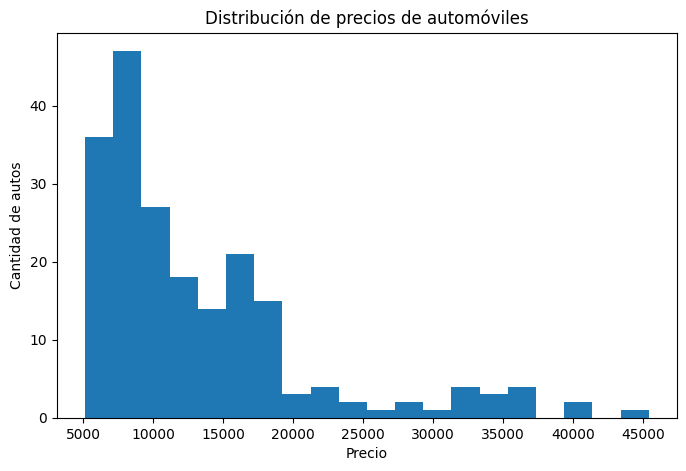

In [19]:
# EDA Visual
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=20)
plt.title("Distribución de precios de automóviles")
plt.xlabel("Precio")
plt.ylabel("Cantidad de autos")
plt.show()

# El histograma permite observar cómo se distribuyen los precios de los automóviles.
Se puede analizar si la mayoría de los vehículos se concentran en precios bajos, medios o altos. Esta visualización ayuda a comprender el comportamiento general de la variable objetivo antes de entrenar el modelo.

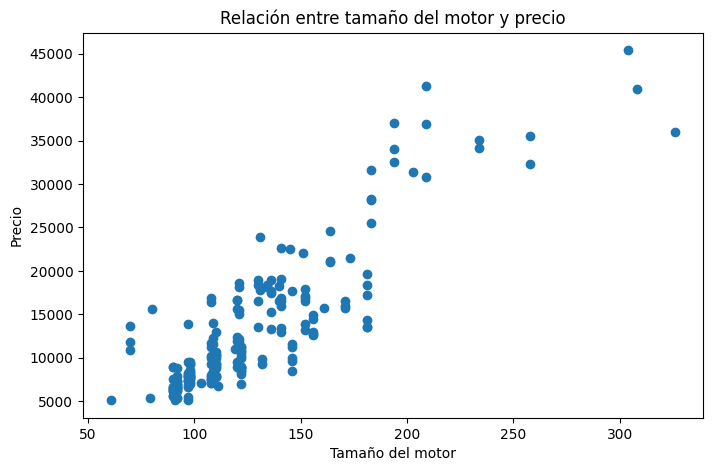

In [20]:
# SCATTERPLOT PRINCIPAL
plt.figure(figsize=(8,5))

plt.scatter(df["enginesize"], df["price"])

plt.xlabel("Tamaño del motor")
plt.ylabel("Precio")

plt.title("Relación entre tamaño del motor y precio")

plt.show()

# El gráfico de dispersión permite observar la relación entre el tamaño del motor (`enginesize`) y el precio del automóvil (`price`).

Se observa una tendencia positiva entre ambas variables, indicando que los vehículos con motores más grandes tienden a presentar precios más elevados. Esto sugiere que existe una relación lineal útil para aplicar un modelo de regresión lineal.

In [21]:
# VARIABLES "X" Y "Y"
X = df[["enginesize"]]

y = df["price"]

In [22]:
# DIVISION TRAIN/TEST
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
# ENTRENAMIENTO DEL MODELO
modelo = LinearRegression()

modelo.fit(X_train, y_train)

LinearRegression()

In [24]:
# PREDICCIONES
y_pred = modelo.predict(X_test)

In [25]:
# METRICAS
print("Intercepto:", modelo.intercept_)

print("Coeficiente:", modelo.coef_)

print("\nEvaluación del modelo:\n")

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R²:", r2)

Intercepto: -7741.765067166594
Coeficiente: [165.84456256]

Evaluación del modelo:

MAE: 2748.6947032901094
MSE: 15465458.96590847
R²: 0.8040958796678975


# Las métricas obtenidas permiten evaluar el desempeño del modelo de regresión lineal.

- El MAE (Error Absoluto Medio) indica el promedio de error entre los valores reales y las predicciones realizadas por el modelo.
- El MSE (Error Cuadrático Medio) penaliza más fuertemente los errores grandes.
- El coeficiente R² permite medir qué proporción de la variabilidad de la variable objetivo puede ser explicada por el modelo.

Un valor de R² cercano a 1 indica un buen ajuste del modelo sobre los datos.

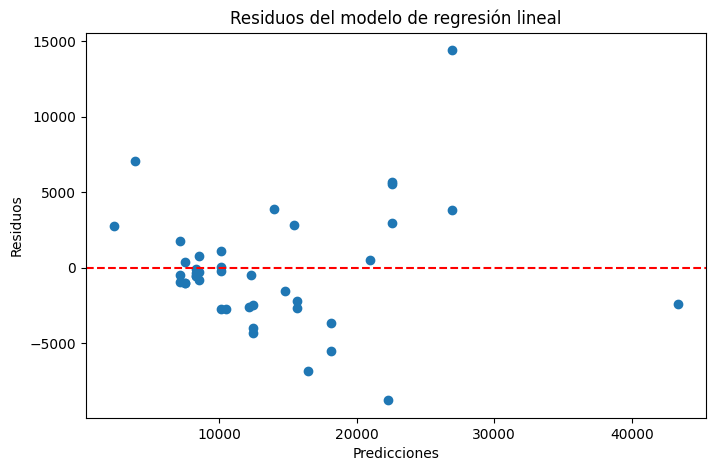

In [26]:
# GRAFICO DE RESIDUOS
residuos = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuos)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicciones")
plt.ylabel("Residuos")

plt.title("Residuos del modelo de regresión lineal")

plt.show()

# El gráfico de residuos permite analizar el comportamiento de los errores del modelo.

Los residuos representan la diferencia entre los valores reales y las predicciones realizadas. Idealmente, los puntos deberían distribuirse alrededor de la línea horizontal ubicada en cero, indicando que el modelo no presenta errores sistemáticos importantes.

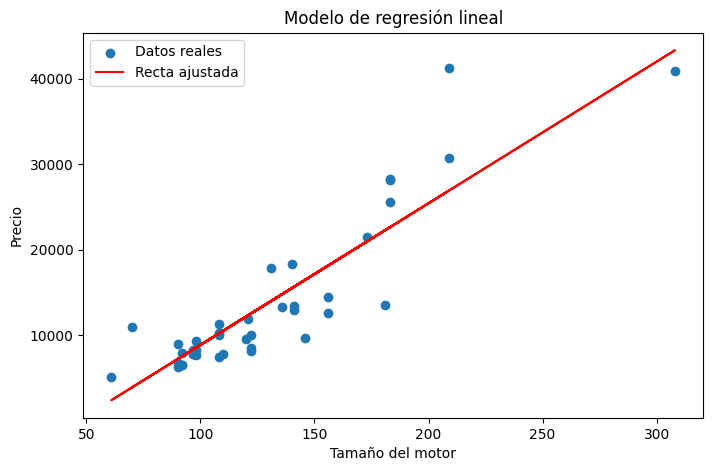

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test, label="Datos reales")

plt.plot(X_test, y_pred, color="red", label="Recta ajustada")

plt.xlabel("Tamaño del motor")
plt.ylabel("Precio")

plt.title("Modelo de regresión lineal")

plt.legend()

plt.show()

El gráfico muestra los datos reales del conjunto de prueba junto con la recta ajustada generada por el modelo de regresión lineal.

La línea roja representa las predicciones realizadas por el modelo, mientras que los puntos azules corresponden a los valores reales observados en el dataset. Se puede observar que existe una tendencia lineal positiva entre ambas variables.

# Conclusión

A partir del desarrollo realizado, fue posible aplicar un modelo de regresión lineal para analizar la relación entre el tamaño del motor de un automóvil y su precio.

Los resultados obtenidos muestran una relación positiva entre ambas variables, indicando que los vehículos con motores más grandes tienden a presentar precios más elevados.

Además, el modelo obtuvo un coeficiente R² de aproximadamente 0.80, lo que indica que una gran parte de la variabilidad del precio puede ser explicada por la variable seleccionada.

Las métricas obtenidas y los gráficos analizados permiten concluir que el modelo presenta un desempeño adecuado para este problema de regresión lineal.